# Problema de empaquetamiento

In [16]:
#Libraries
import dimod
import networkx as nx
import matplotlib.pyplot as plt
from dwave.samplers import SimulatedAnnealingSampler
import random
import numpy as np
from itertools import combinations
import itertools
import pickle
from IPython.display import Image
from collections import defaultdict
import math
from typing import Dict, List, Tuple, Any

## Parte 1: Empaquetamiento 1D


== Ejemplo A (el de antes) ==
lengths = [2, 5, 4, 7, 1, 3, 8] C = 10
vars = 84 K = 4
energy = 5.0 time_s = 6.518759700000373
feasible? = True bins_used = 5


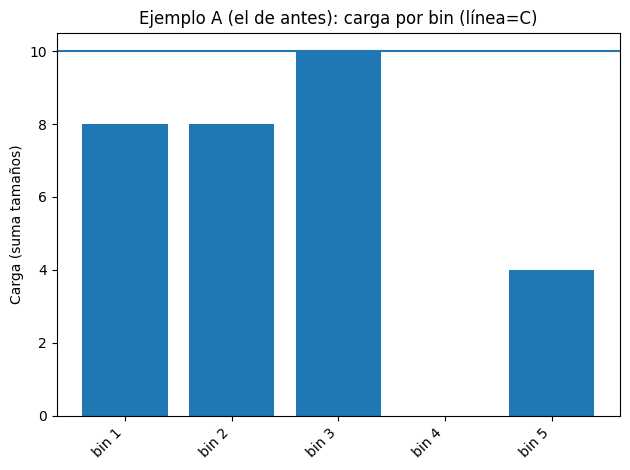


== Ejemplo B ==
lengths = [6, 6, 6, 6, 4, 4, 4] C = 10
vars = 84 K = 4
energy = 5.0 time_s = 5.447255099999893
feasible? = True bins_used = 5


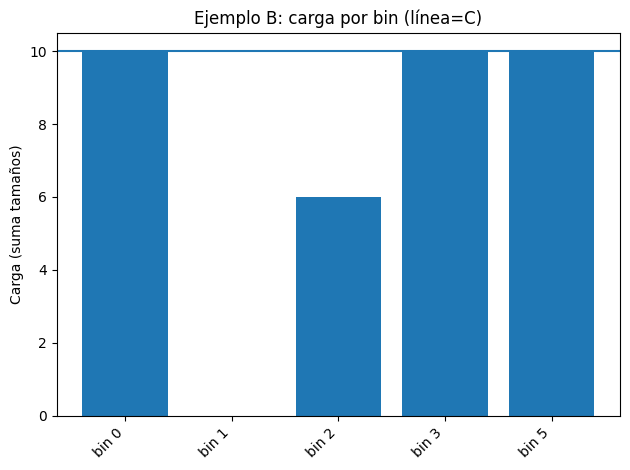


== Ejemplo C ==
lengths = [9, 9, 2, 2, 2, 2, 2] C = 10
vars = 84 K = 4
energy = 4.0 time_s = 6.1107968000001165
feasible? = True bins_used = 4


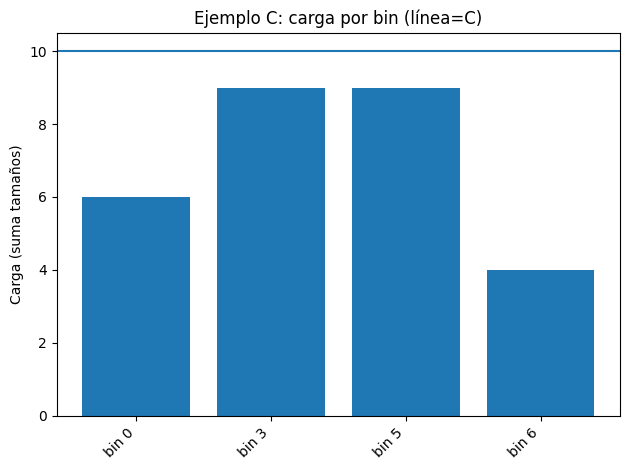


=== Benchmark límite 1D (subiendo n) ===


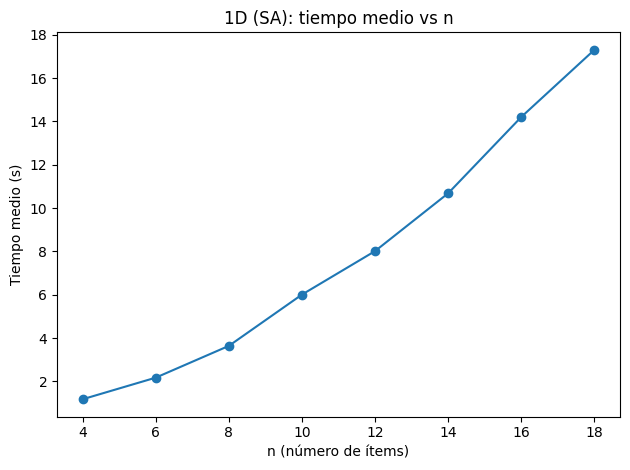

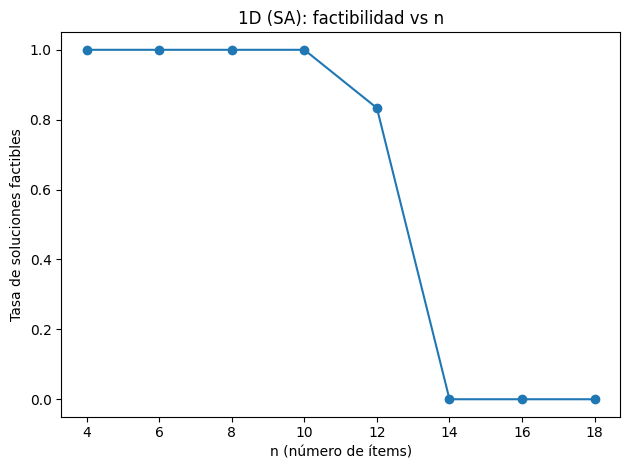

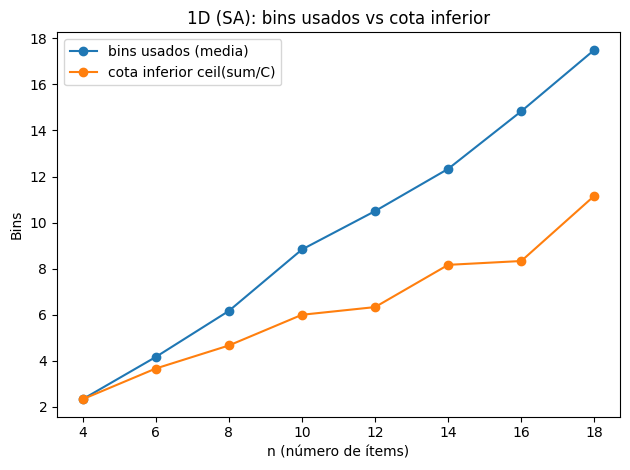


Resumen (por n):
 n | num_vars | tiempo_med(s) | factible(%) | bins_med | lb_med
 4 |       36 |       1.1737 |     100.0 |     2.33 |   2.33
 6 |       66 |       2.1710 |     100.0 |     4.17 |   3.67
 8 |      104 |       3.6378 |     100.0 |     6.17 |   4.67
10 |      150 |       6.0055 |     100.0 |     8.83 |   6.00
12 |      204 |       8.0142 |      83.3 |    10.50 |   6.33
14 |      266 |      10.6835 |       0.0 |    12.33 |   8.17
16 |      336 |      14.2058 |       0.0 |    14.83 |   8.33
18 |      414 |      17.3069 |       0.0 |    17.50 |  11.17


In [2]:
import math
import time
import random
from itertools import combinations
from typing import Dict, List, Tuple, Any

import matplotlib.pyplot as plt

import dimod
from dwave.samplers import SimulatedAnnealingSampler


# -------------------------
# Utilidades matemáticas
# -------------------------

def ceil_log2(x: int) -> int:
    """ceil(log2(x)) para x>=1"""
    return int(math.ceil(math.log2(x)))


# -------------------------
# Núcleo: añadir (c + Σ a_i x_i)^2 a un BQM
# -------------------------
def add_squared_linear_expression(
    bqm: dimod.BinaryQuadraticModel,
    terms: Dict[str, float],
    constant: float,
    weight: float,
) -> None:
    """
    Añade al BQM el término:
        weight * (constant + sum_i terms[var_i] * x_i)^2

    Expansión usando x^2 = x (binarias):
      (c + Σ a_i x_i)^2 =
         c^2
       + Σ (2c a_i + a_i^2) x_i
       + 2 Σ_{i<j} a_i a_j x_i x_j
    """
    # Constante
    bqm.offset += weight * (constant ** 2)

    # Términos lineales
    for var, a in terms.items():
        bqm.add_variable(var, 0.0)
        bqm.linear[var] += weight * (2.0 * constant * a + a * a)

    # Términos cuadráticos (pares sin duplicar)
    keys = list(terms.keys())
    for v1, v2 in combinations(keys, 2):
        a1, a2 = terms[v1], terms[v2]
        bqm.add_interaction(v1, v2, weight * (2.0 * a1 * a2))


# -------------------------
# Constructor genérico: "bin packing" con tamaños y capacidad
# (sirve para 1D: size=l_i, cap=C; y para 3D volumétrico: size=V_i, cap=Vbin=LHW)
# -------------------------
def build_binpacking_bqm(
    sizes: List[int],
    cap: int,
    num_bins: int | None = None,
    alpha: float = 1.0,
    lam_assign: float = 80.0,
    lam_cap: float = 80.0,
) -> Tuple[dimod.BinaryQuadraticModel, Dict[str, Any]]:
    """
    Modelo (caso I o caso II volumétrico):
      variables: u_{i,j}, v_j
      objetivo: min alpha * Σ_j v_j
      asignación única: Σ_j u_{i,j}=1
      capacidad: Σ_i size_i u_{i,j} ≤ cap * v_j

    Desigualdad -> igualdad con holgura s_j >= 0:
      Σ_i size_i u_{i,j} + s_j = cap * v_j
      s_j representada en bits: s_j = Σ_k 2^k s_{j,k}
    """
    n = len(sizes)
    if num_bins is None:
        num_bins = n  # cota superior típica

    if cap <= 0:
        raise ValueError("capacidad cap debe ser > 0")
    if any(si <= 0 for si in sizes):
        raise ValueError("todos los tamaños deben ser > 0")

    # Bits holgura para representar 0..cap
    K = ceil_log2(cap + 1)

    bqm = dimod.BinaryQuadraticModel({}, {}, 0.0, vartype=dimod.BINARY)

    def u(i: int, j: int) -> str: return f"u_{i}_{j}"
    def v(j: int) -> str: return f"v_{j}"
    def s(j: int, k: int) -> str: return f"s_{j}_{k}"

    # Objetivo: alpha * Σ v_j
    for j in range(num_bins):
        bqm.add_variable(v(j), alpha)

    # Asignación única: lam_assign * (1 - Σ u_{i,j})^2
    for i in range(n):
        terms = {u(i, j): -1.0 for j in range(num_bins)}
        add_squared_linear_expression(bqm, terms=terms, constant=1.0, weight=lam_assign)

    # Capacidad: lam_cap * (Σ size_i u_{i,j} + Σ 2^k s_{j,k} - cap*v_j)^2
    for j in range(num_bins):
        terms: Dict[str, float] = {}
        for i, si in enumerate(sizes):
            terms[u(i, j)] = float(si)
        for k in range(K):
            terms[s(j, k)] = float(2 ** k)
        terms[v(j)] = float(-cap)
        add_squared_linear_expression(bqm, terms=terms, constant=0.0, weight=lam_cap)

    info = {
        "n_items": n,
        "num_bins": num_bins,
        "cap": cap,
        "slack_bits_K": K,
        "num_variables": len(bqm.variables),
        "alpha": alpha,
        "lam_assign": lam_assign,
        "lam_cap": lam_cap,
    }
    return bqm, info


# -------------------------
# Resolver y decodificar
# -------------------------
def decode_solution(sample: Dict[str, int], sizes: List[int], cap: int, num_bins: int) -> Dict[str, Any]:
    # 1) Fuerza todas las variables del sample a int "de Python"
    #    (evita numpy.int8 / dtype raros)
    sample_py = {k: int(v) for k, v in sample.items()}
    
    n = len(sizes)
    sizes = [int(x) for x in sizes]
    cap = int(cap)

    def u(i, j): return sample_py.get(f"u_{i}_{j}", 0)
    def v(j): return sample_py.get(f"v_{j}", 0)

    # Asignación item->bin (primer j con u=1)
    assignment = [-1] * n
    bins_to_items = {j: [] for j in range(num_bins)}
    for i in range(n):
        chosen = [j for j in range(num_bins) if u(i, j) == 1]
        assignment[i] = chosen[0] if chosen else -1
        if chosen:
            bins_to_items[chosen[0]].append(i)

    ok_assign = all(sum(u(i, j) for j in range(num_bins)) == 1 for i in range(n))

    used_bins = [j for j in range(num_bins) if v(j) == 1]
    bins_used_count = sum(v(j) for j in range(num_bins))

    cap_violations = []
    loads = []
    for j in range(num_bins):
        load = sum(sizes[i] * u(i, j) for i in range(n))
        loads.append(load)
        rhs = cap * v(j)
        if load > rhs:
            cap_violations.append((j, load, rhs))

    feasible = ok_assign and (len(cap_violations) == 0)

    return {
        "assignment": assignment,
        "bins_to_items": bins_to_items,
        "used_bins": used_bins,
        "bins_used_count": bins_used_count,
        "ok_assign": ok_assign,
        "cap_violations": cap_violations,
        "feasible": feasible,
        "loads": loads,
    }


def solve_with_sa(
    sizes: List[int],
    cap: int,
    num_bins: int | None = None,
    num_reads: int = 2000,
    seed: int = 123,
    alpha: float = 1.0,
    lam_assign: float = 80.0,
    lam_cap: float = 80.0,
) -> Dict[str, Any]:
    bqm, info = build_binpacking_bqm(
        sizes=sizes, cap=cap, num_bins=num_bins,
        alpha=alpha, lam_assign=lam_assign, lam_cap=lam_cap
    )

    sampler = SimulatedAnnealingSampler()
    t0 = time.perf_counter()
    sampleset = sampler.sample(bqm, num_reads=num_reads, seed=seed)
    t1 = time.perf_counter()

    best = sampleset.first
    decoded = decode_solution(best.sample, sizes, cap, info["num_bins"])

    return {
        "bqm": bqm,
        "info": info,
        "sampleset": sampleset,
        "best_energy": best.energy,
        "best_sample": best.sample,
        "decoded": decoded,
        "solve_time_s": (t1 - t0),
    }


# -------------------------
# Plots útiles (1D)
# -------------------------
def plot_bin_loads(decoded: Dict[str, Any], cap: int, title: str):
    used = decoded["used_bins"]
    loads = decoded["loads"]

    plt.figure()
    if used:
        xs = list(range(len(used)))
        ys = [loads[j] for j in used]
        plt.bar(xs, ys)
        plt.axhline(cap)
        plt.xticks(xs, [f"bin {j}" for j in used], rotation=45, ha="right")
        plt.ylabel("Carga (suma tamaños)")
        plt.title(title)
    else:
        plt.title(title + " (sin bins activos)")
    plt.tight_layout()
    plt.show()


# -------------------------
# Benchmark “límite”: subir n y B y ver tiempo/éxito
# -------------------------
def benchmark_1d_limits(
    C: int,
    n_values: List[int],
    B_policy: str = "n",     # "n" para B=n, o "fixed"
    fixed_B: int = 10,
    trials: int = 8,
    num_reads: int = 1500,
    alpha: float = 1.0,
    lam_assign: float = 120.0,
    lam_cap: float = 120.0,
    seed: int = 0,
) -> List[Dict[str, Any]]:
    rng = random.Random(seed)
    sampler = SimulatedAnnealingSampler()
    results = []

    for n in n_values:
        B = n if B_policy == "n" else fixed_B

        for t in range(trials):
            lengths = [rng.randint(1, C) for _ in range(n)]

            bqm, info = build_binpacking_bqm(
                sizes=lengths, cap=C, num_bins=B,
                alpha=alpha, lam_assign=lam_assign, lam_cap=lam_cap
            )

            t0 = time.perf_counter()
            ss = sampler.sample(bqm, num_reads=num_reads, seed=rng.randint(0, 10**9))
            t1 = time.perf_counter()

            best = ss.first
            dec = decode_solution(best.sample, lengths, C, B)

            results.append({
                "n": n,
                "B": B,
                "C": C,
                "trial": t,
                "num_vars": info["num_variables"],
                "K": info["slack_bits_K"],
                "time_s": t1 - t0,
                "energy": best.energy,
                "feasible": dec["feasible"],
                "bins_used": dec["bins_used_count"],
                "lower_bound_bins": math.ceil(sum(lengths)/C),
            })

    return results


def summarize_and_plot_benchmark(rows: List[Dict[str, Any]], title_prefix: str = "1D"):
    # agrega por n
    rows_sorted = sorted(rows, key=lambda r: (r["n"], r["trial"]))
    n_values = sorted(set(r["n"] for r in rows_sorted))

    agg = []
    for n in n_values:
        chunk = [r for r in rows_sorted if r["n"] == n]
        mean_time = sum(r["time_s"] for r in chunk) / len(chunk)
        feasible_rate = sum(1 for r in chunk if r["feasible"]) / len(chunk)
        mean_bins = sum(r["bins_used"] for r in chunk) / len(chunk)
        mean_lb = sum(r["lower_bound_bins"] for r in chunk) / len(chunk)
        num_vars = chunk[0]["num_vars"]
        agg.append((n, mean_time, feasible_rate, mean_bins, mean_lb, num_vars))

    # plot tiempo
    plt.figure()
    plt.plot([a[0] for a in agg], [a[1] for a in agg], marker="o")
    plt.xlabel("n (número de ítems)")
    plt.ylabel("Tiempo medio (s)")
    plt.title(f"{title_prefix}: tiempo medio vs n")
    plt.tight_layout()
    plt.show()

    # plot factibilidad
    plt.figure()
    plt.plot([a[0] for a in agg], [a[2] for a in agg], marker="o")
    plt.ylim(-0.05, 1.05)
    plt.xlabel("n (número de ítems)")
    plt.ylabel("Tasa de soluciones factibles")
    plt.title(f"{title_prefix}: factibilidad vs n")
    plt.tight_layout()
    plt.show()

    # plot bins vs cota inferior
    plt.figure()
    plt.plot([a[0] for a in agg], [a[3] for a in agg], marker="o", label="bins usados (media)")
    plt.plot([a[0] for a in agg], [a[4] for a in agg], marker="o", label="cota inferior ceil(sum/C)")
    plt.xlabel("n (número de ítems)")
    plt.ylabel("Bins")
    plt.title(f"{title_prefix}: bins usados vs cota inferior")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # imprime tablita
    print("\nResumen (por n):")
    print(" n | num_vars | tiempo_med(s) | factible(%) | bins_med | lb_med")
    for n, mt, fr, mb, mlb, nv in agg:
        print(f"{n:2d} | {nv:8d} | {mt:12.4f} | {100*fr:9.1f} | {mb:8.2f} | {mlb:6.2f}")


# -------------------------
# MAIN: ejemplos + benchmark
# -------------------------
if __name__ == "__main__":
    # Caso I (1D) según la práctica: tamaños l_i, capacidad C :contentReference[oaicite:2]{index=2}
    examples_1d = [
        ("Ejemplo A (el de antes)", [2, 5, 4, 7, 1, 3, 8], 10),
        ("Ejemplo B",               [6, 6, 6, 6, 4, 4, 4], 10),
        ("Ejemplo C",               [9, 9, 2, 2, 2, 2, 2], 10),
    ]

    for name, lengths, C in examples_1d:
        print("\n==", name, "==")
        out = solve_with_sa(lengths, C, num_bins=len(lengths), num_reads=3000, seed=7,
                            lam_assign=120.0, lam_cap=120.0)
        dec = out["decoded"]
        print("lengths =", lengths, "C =", C)
        print("vars =", out["info"]["num_variables"], "K =", out["info"]["slack_bits_K"])
        print("energy =", out["best_energy"], "time_s =", out["solve_time_s"])
        print("feasible? =", dec["feasible"], "bins_used =", dec["bins_used_count"])
        if not dec["feasible"]:
            print("  violaciones cap:", dec["cap_violations"])
        plot_bin_loads(dec, C, title=f"{name}: carga por bin (línea=C)")

    # Benchmark “límite” 1D: sube n (por defecto B=n)
    print("\n=== Benchmark límite 1D (subiendo n) ===")
    rows = benchmark_1d_limits(
        C=10,
        n_values=[4, 6, 8, 10, 12, 14, 16, 18],
        B_policy="n",
        trials=6,
        num_reads=1500,
        lam_assign=150.0,
        lam_cap=150.0,
        seed=42,
    )
    summarize_and_plot_benchmark(rows, title_prefix="1D (SA)")


## Parte 2: Empaquetamiento 3D

In [10]:
def volumes_from_items(items_3d: List[Tuple[int,int,int]]) -> List[int]:
    """items_3d = [(l,w,h), ...] -> [V_i]"""
    return [int(l*w*h) for (l,w,h) in items_3d]

def container_volume(L: int, W: int, H: int) -> int:
    return int(L*W*H)


In [12]:
def run_and_report(case_name: str, sizes: List[int], cap: int, num_reads=3000, seed=7):
    out = solve_with_sa(
        sizes=sizes,
        cap=cap,
        num_bins=len(sizes),       # mismo criterio que usabas en 1D
        num_reads=num_reads,
        seed=seed,
        lam_assign=120.0,
        lam_cap=120.0,
    )
    dec = out["decoded"]
    print(f"\n== {case_name} ==")
    print("sizes =", sizes)
    print("cap   =", cap)
    print("vars  =", out["info"]["num_variables"], "K =", out["info"]["slack_bits_K"])
    print("energy =", out["best_energy"], "time_s =", out["solve_time_s"])
    print("feasible? =", dec["feasible"], "bins_used =", dec["bins_used_count"])
    if not dec["feasible"]:
        print("  violaciones cap:", dec["cap_violations"])
    plot_bin_loads(dec, cap, title=f"{case_name}: carga por bin (línea=cap)")
    
    for j in dec["used_bins"]:
        items = dec["bins_to_items"][j]
        print(f"  bin {j}: items={items}, load={dec['loads'][j]}/{cap}")

    return out


In [13]:
def benchmark_limits_generic(
    make_sizes_fn,          # función: (n, rng) -> List[int]
    cap: int,
    n_values: List[int],
    B_policy: str = "n",
    fixed_B: int = 10,
    trials: int = 6,
    num_reads: int = 1500,
    alpha: float = 1.0,
    lam_assign: float = 150.0,
    lam_cap: float = 150.0,
    seed: int = 0,
) -> List[Dict[str, Any]]:
    rng = random.Random(seed)
    sampler = SimulatedAnnealingSampler()
    rows = []

    for n in n_values:
        B = n if B_policy == "n" else fixed_B

        for t in range(trials):
            sizes = make_sizes_fn(n, rng)

            bqm, info = build_binpacking_bqm(
                sizes=sizes, cap=cap, num_bins=B,
                alpha=alpha, lam_assign=lam_assign, lam_cap=lam_cap
            )

            t0 = time.perf_counter()
            ss = sampler.sample(bqm, num_reads=num_reads, seed=rng.randint(0, 10**9))
            t1 = time.perf_counter()

            best = ss.first
            dec = decode_solution(best.sample, sizes, cap, B)

            rows.append({
                "n": n, "B": B, "cap": cap, "trial": t,
                "num_vars": info["num_variables"], "K": info["slack_bits_K"],
                "time_s": t1 - t0,
                "energy": best.energy,
                "feasible": dec["feasible"],
                "bins_used": dec["bins_used_count"],
                "lower_bound_bins": math.ceil(sum(sizes)/cap),
            })

    return rows


In [14]:
def make_3d_volumes(n: int, rng: random.Random, max_dim: int, Vbin: int) -> List[int]:
    """
    Genera n cajas (l,w,h) con l,w,h en [1,max_dim] y devuelve volúmenes.
    Rechaza cajas con V_i > Vbin para que el modelo volumétrico no sea imposible.
    """
    vols = []
    while len(vols) < n:
        l = rng.randint(1, max_dim)
        w = rng.randint(1, max_dim)
        h = rng.randint(1, max_dim)
        v = l*w*h
        if v <= Vbin:
            vols.append(v)
    return vols



== 1D Ejemplo A ==
sizes = [2, 5, 4, 7, 1, 3, 8]
cap   = 10
vars  = 84 K = 4
energy = 5.0 time_s = 5.79839709999942
feasible? = True bins_used = 5


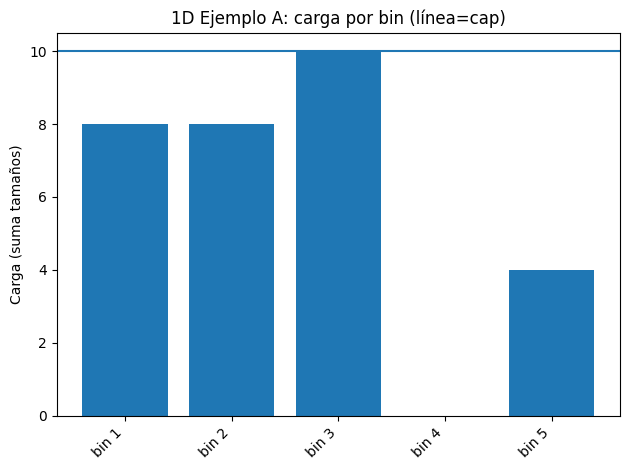


== 1D Ejemplo B ==
sizes = [6, 6, 6, 6, 4, 4, 4]
cap   = 10
vars  = 84 K = 4
energy = 5.0 time_s = 5.361484899999596
feasible? = True bins_used = 5


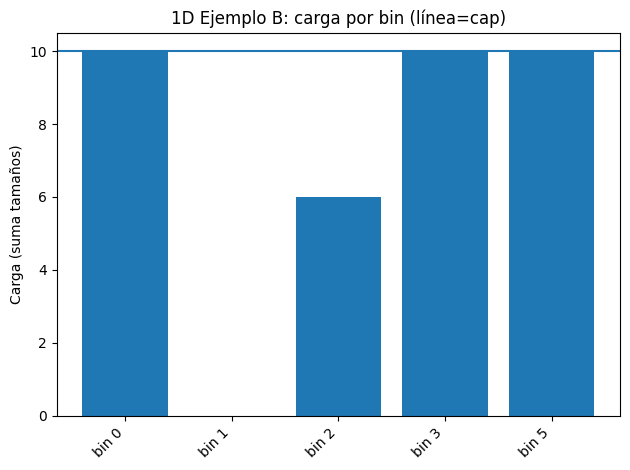


== 1D Ejemplo C ==
sizes = [9, 9, 2, 2, 2, 2, 2]
cap   = 10
vars  = 84 K = 4
energy = 4.0 time_s = 5.870379099999809
feasible? = True bins_used = 4


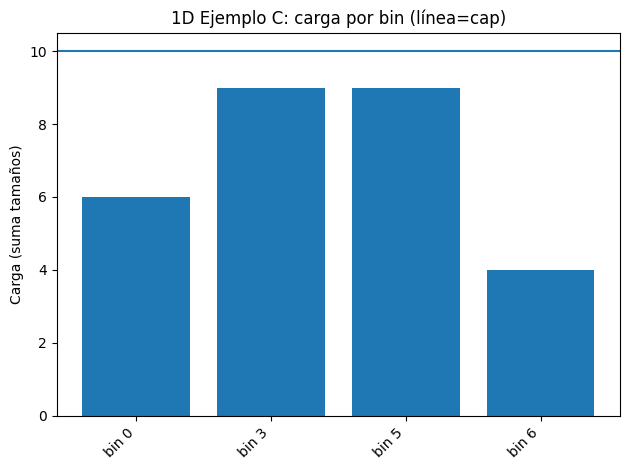


=== Benchmark límite 1D (subiendo n, B=n) ===


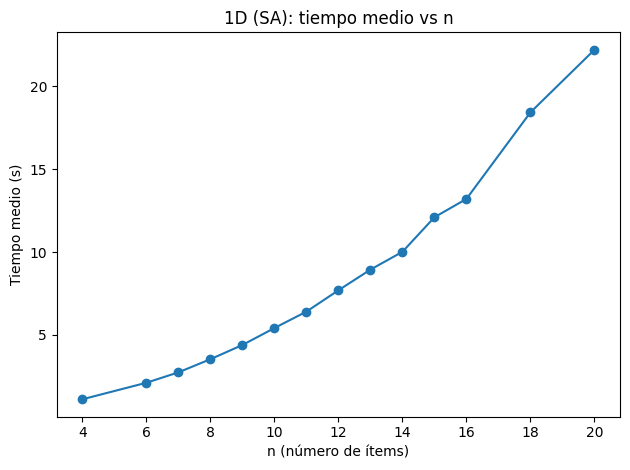

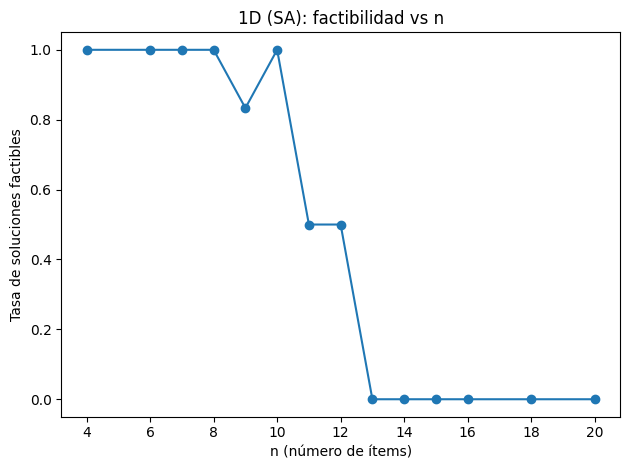

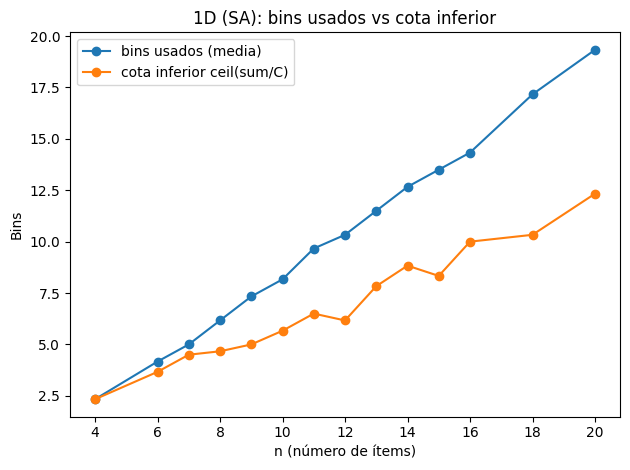


Resumen (por n):
 n | num_vars | tiempo_med(s) | factible(%) | bins_med | lb_med
 4 |       36 |       1.1184 |     100.0 |     2.33 |   2.33
 6 |       66 |       2.1156 |     100.0 |     4.17 |   3.67
 7 |       84 |       2.7440 |     100.0 |     5.00 |   4.50
 8 |      104 |       3.5360 |     100.0 |     6.17 |   4.67
 9 |      126 |       4.3935 |      83.3 |     7.33 |   5.00
10 |      150 |       5.4162 |     100.0 |     8.17 |   5.67
11 |      176 |       6.4071 |      50.0 |     9.67 |   6.50
12 |      204 |       7.6942 |      50.0 |    10.33 |   6.17
13 |      234 |       8.9399 |       0.0 |    11.50 |   7.83
14 |      266 |      10.0137 |       0.0 |    12.67 |   8.83
15 |      300 |      12.0991 |       0.0 |    13.50 |   8.33
16 |      336 |      13.2055 |       0.0 |    14.33 |  10.00
18 |      414 |      18.4250 |       0.0 |    17.17 |  10.33
20 |      500 |      22.2021 |       0.0 |    19.33 |  12.33


ValueError: too many values to unpack (expected 3)

In [8]:
if __name__ == "__main__":

    # -------------------
    # CASO I (1D)
    # -------------------
    examples_1d = [
        ("1D Ejemplo A", [2, 5, 4, 7, 1, 3, 8], 10),
        ("1D Ejemplo B", [6, 6, 6, 6, 4, 4, 4], 10),
        ("1D Ejemplo C", [9, 9, 2, 2, 2, 2, 2], 10),
    ]

    for name, lengths, C in examples_1d:
        run_and_report(name, sizes=lengths, cap=C)

    print("\n=== Benchmark límite 1D (subiendo n, B=n) ===")
    rows_1d = benchmark_limits_generic(
        make_sizes_fn=lambda n, rng: [rng.randint(1, 10) for _ in range(n)],
        cap=10,
        n_values=[4, 6,7, 8,9, 10,11, 12, 13, 14, 15, 16, 18, 20],
        B_policy="n",
        trials=6,
        num_reads=1500,
        seed=42,
    )
    summarize_and_plot_benchmark(rows_1d, title_prefix="1D (SA)")

    # -------------------
    # CASO II (3D simplificado por volumen)
    # -------------------
    items1 = [(2,3,4), (1,5,6), (2,2,5)]
    V1 = volumes_from_items(items1)

    L, W, H = 4, 6, 6
    Vbin1 = container_volume(L, W, H)
    
    items2 = [(2,3,4,8), (1,5,6,7), (2,2,5,9)]
    V2 = volumes_from_items(items2)

    L, W, H = 8, 7, 9
    Vbin2 = container_volume(L, W, H)
    
    items3 = [(2,3,4,8,2), (1,5,6,7,9), (2,2,5,9,6)]
    V3 = volumes_from_items(items3)

    L, W, H = 8, 9, 9
    Vbin3 = container_volume(L, W, H)
    
    examples_3d = [
        ("3D Ejemplo A", items1, Vbin1),
        ("3D Ejemplo B", items2, Vbin2),
        ("3D Ejemplo C", items3, Vbin3),
    ]
    
    for name, lengths, C in examples_3d:
        run_and_report(name, sizes=volumes, cap=Vbin)
    


    run_and_report("3D(vol) Ejemplo D", sizes=V, cap=Vbin)

    print("\n=== Benchmark límite 3D(vol) (subiendo n, B=n) ===")
    max_dim = 6  # controla lo grandes que salen las cajas (y los volúmenes)
    rows_3d = benchmark_limits_generic(
        make_sizes_fn=lambda n, rng: make_3d_volumes(n, rng, max_dim=max_dim, Vbin=Vbin),
        cap=Vbin,
        n_values=[4,5, 6,7, 8,9, 10,11, 12,13, 14, 16, 18, 20],
        B_policy="n",
        trials=6,
        num_reads=1500,
        seed=43,
    )
    summarize_and_plot_benchmark(rows_3d, title_prefix="3D (volumen) (SA)")



== 1D Ejemplo A ==
sizes = [2, 5, 4, 7, 1, 3, 8]
cap   = 10
vars  = 84 K = 4
energy = 5.0 time_s = 5.832633300000452
feasible? = True bins_used = 5


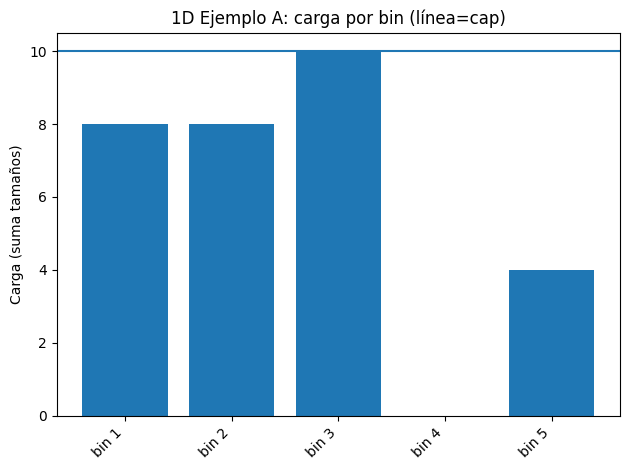

  bin 1: items=[6], load=8/10
  bin 2: items=[3, 4], load=8/10
  bin 3: items=[0, 1, 5], load=10/10
  bin 4: items=[], load=0/10
  bin 5: items=[2], load=4/10

== 1D Ejemplo B ==
sizes = [6, 6, 6, 6, 4, 4, 4]
cap   = 10
vars  = 84 K = 4
energy = 5.0 time_s = 5.664872399996966
feasible? = True bins_used = 5


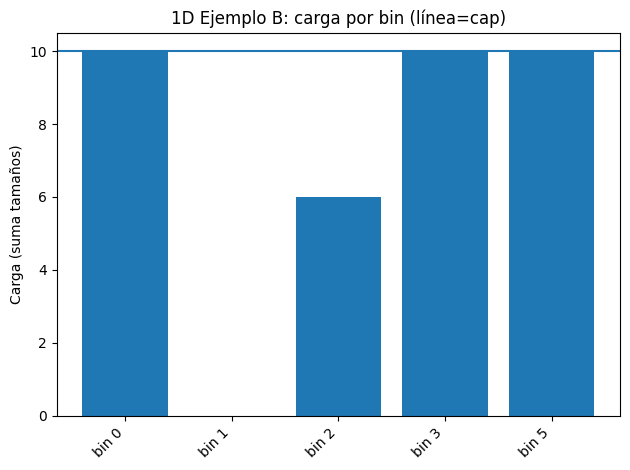

  bin 0: items=[0, 6], load=10/10
  bin 1: items=[], load=0/10
  bin 2: items=[2], load=6/10
  bin 3: items=[3, 4], load=10/10
  bin 5: items=[1, 5], load=10/10

== 1D Ejemplo C ==
sizes = [9, 9, 2, 2, 2, 2, 2]
cap   = 10
vars  = 84 K = 4
energy = 4.0 time_s = 5.991179799995734
feasible? = True bins_used = 4


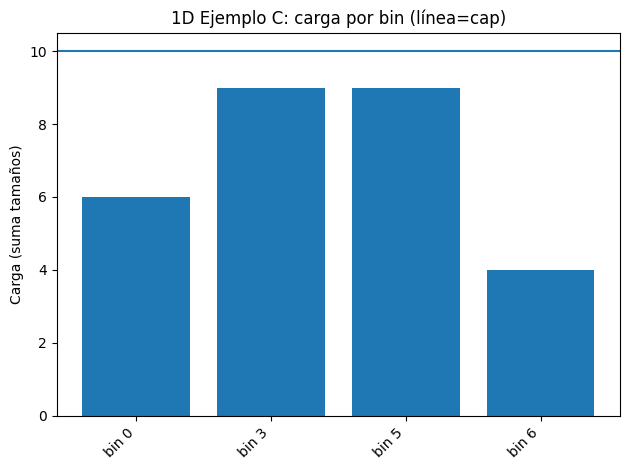

  bin 0: items=[2, 4, 5], load=6/10
  bin 3: items=[0], load=9/10
  bin 5: items=[1], load=9/10
  bin 6: items=[3, 6], load=4/10

=== Benchmark límite 1D (subiendo n, B=n) ===


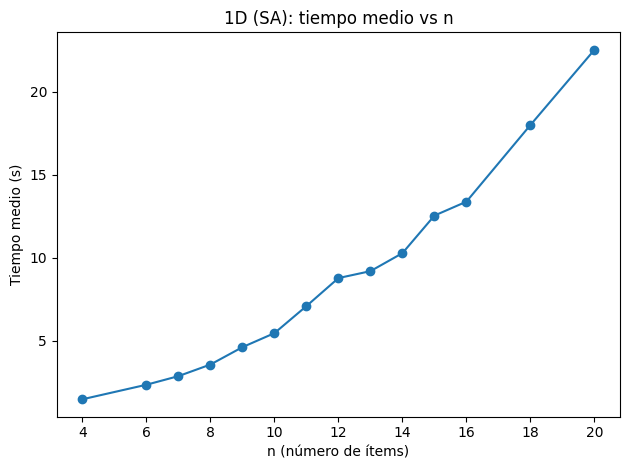

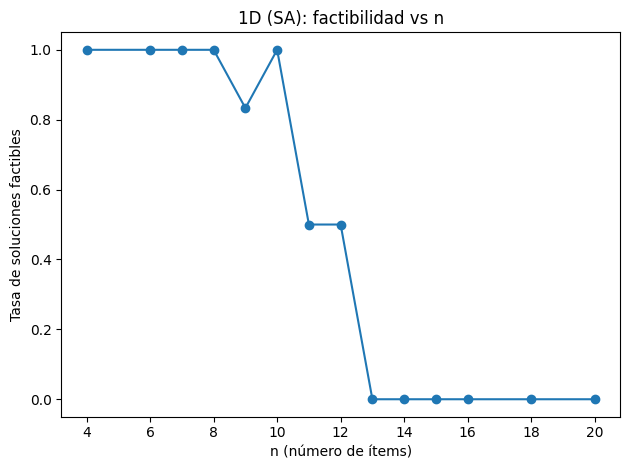

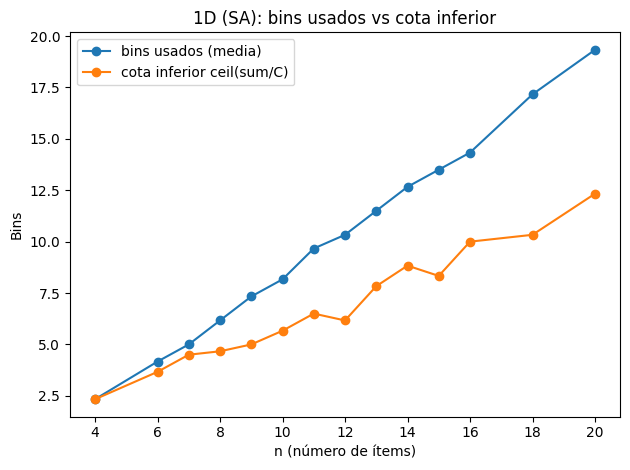


Resumen (por n):
 n | num_vars | tiempo_med(s) | factible(%) | bins_med | lb_med
 4 |       36 |       1.4765 |     100.0 |     2.33 |   2.33
 6 |       66 |       2.3523 |     100.0 |     4.17 |   3.67
 7 |       84 |       2.8715 |     100.0 |     5.00 |   4.50
 8 |      104 |       3.5708 |     100.0 |     6.17 |   4.67
 9 |      126 |       4.6177 |      83.3 |     7.33 |   5.00
10 |      150 |       5.4627 |     100.0 |     8.17 |   5.67
11 |      176 |       7.0944 |      50.0 |     9.67 |   6.50
12 |      204 |       8.7820 |      50.0 |    10.33 |   6.17
13 |      234 |       9.1990 |       0.0 |    11.50 |   7.83
14 |      266 |      10.2847 |       0.0 |    12.67 |   8.83
15 |      300 |      12.5482 |       0.0 |    13.50 |   8.33
16 |      336 |      13.3886 |       0.0 |    14.33 |  10.00
18 |      414 |      18.0081 |       0.0 |    17.17 |  10.33
20 |      500 |      22.5424 |       0.0 |    19.33 |  12.33

== 3D(vol) Ejemplo A ==
sizes = [24, 30, 20]
cap   = 144
vars  

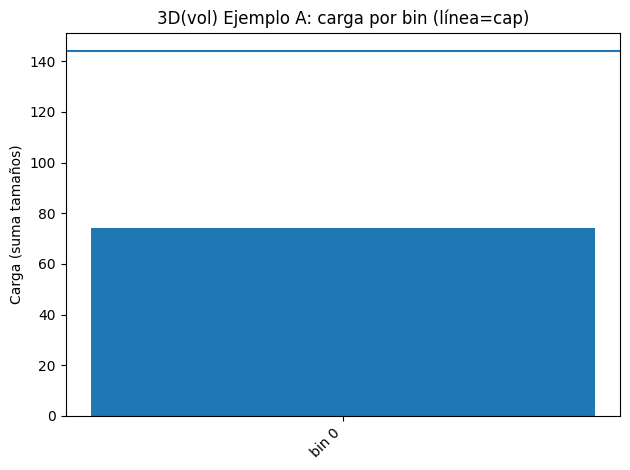

  bin 0: items=[0, 1, 2], load=74/144

== 3D(vol) Ejemplo B ==
sizes = [27, 40, 36, 28]
cap   = 216
vars  = 52 K = 8
energy = 1.0 time_s = 2.9589347000001
feasible? = True bins_used = 1


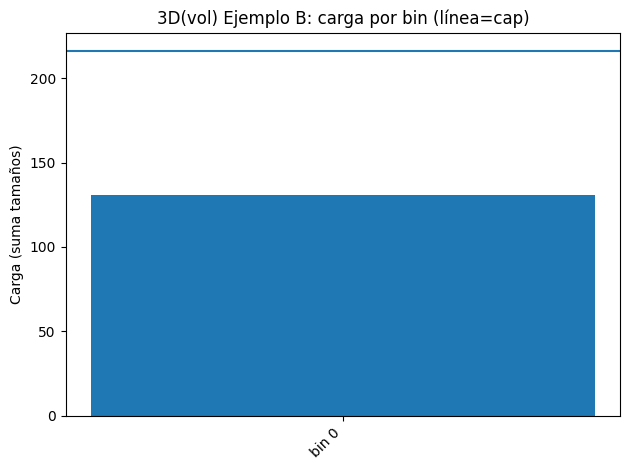

  bin 0: items=[0, 1, 2, 3], load=131/216

== 3D(vol) Ejemplo C ==
sizes = [64, 30, 36, 28, 32]
cap   = 336
vars  = 75 K = 9
energy = 2.0 time_s = 4.551830399999744
feasible? = True bins_used = 2


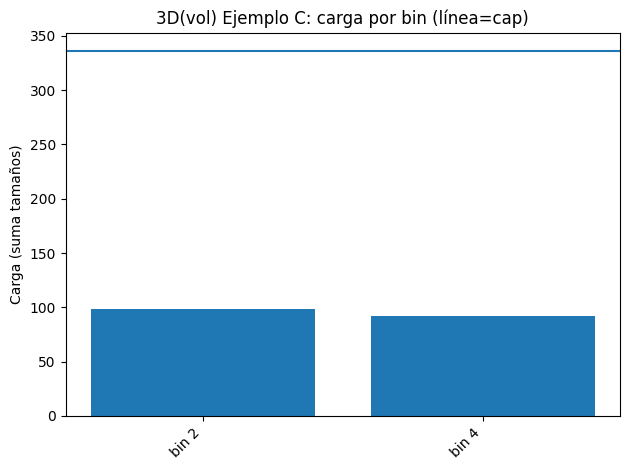

  bin 2: items=[1, 2, 4], load=98/336
  bin 4: items=[0, 3], load=92/336

=== Benchmark límite 3D(vol) (subiendo n, B=n) ===


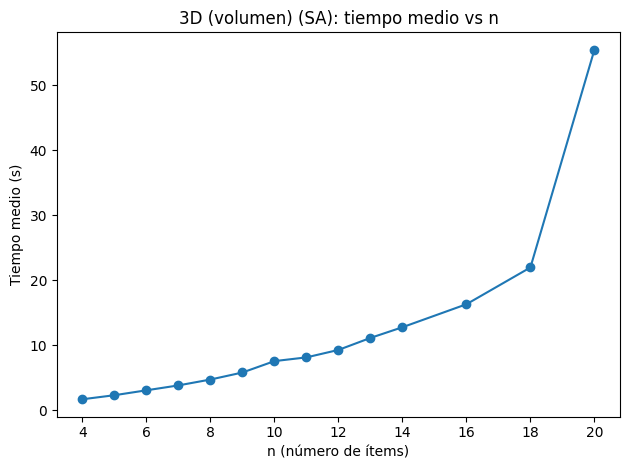

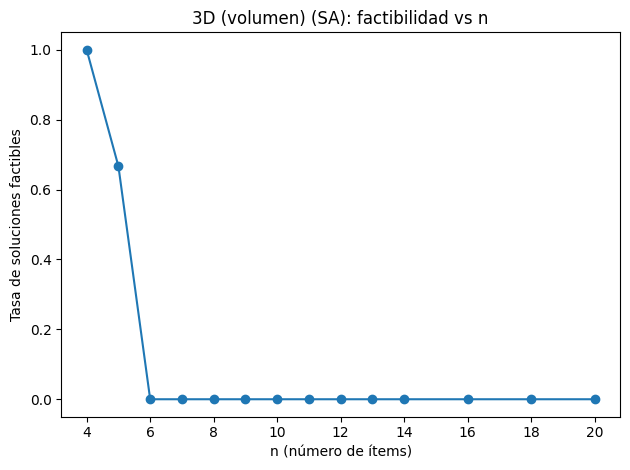

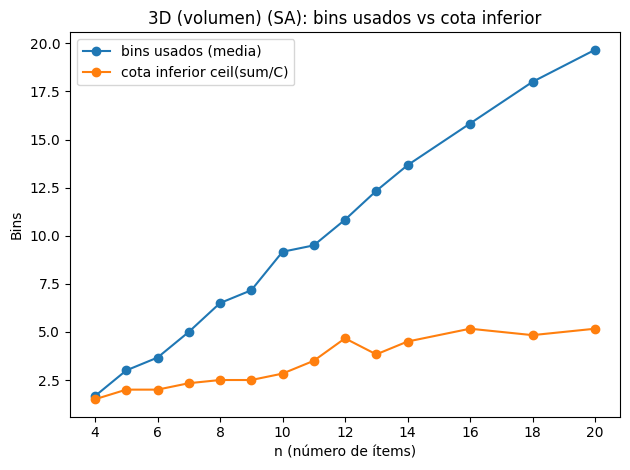


Resumen (por n):
 n | num_vars | tiempo_med(s) | factible(%) | bins_med | lb_med
 4 |       56 |       1.6569 |     100.0 |     1.67 |   1.50
 5 |       75 |       2.2791 |      66.7 |     3.00 |   2.00
 6 |       96 |       3.0352 |       0.0 |     3.67 |   2.00
 7 |      119 |       3.7899 |       0.0 |     5.00 |   2.33
 8 |      144 |       4.6930 |       0.0 |     6.50 |   2.50
 9 |      171 |       5.7736 |       0.0 |     7.17 |   2.50
10 |      200 |       7.5270 |       0.0 |     9.17 |   2.83
11 |      231 |       8.0999 |       0.0 |     9.50 |   3.50
12 |      264 |       9.2478 |       0.0 |    10.83 |   4.67
13 |      299 |      11.0946 |       0.0 |    12.33 |   3.83
14 |      336 |      12.7393 |       0.0 |    13.67 |   4.50
16 |      416 |      16.2777 |       0.0 |    15.83 |   5.17
18 |      504 |      21.9383 |       0.0 |    18.00 |   4.83
20 |      600 |      55.4301 |       0.0 |    19.67 |   5.17


In [17]:
if __name__ == "__main__":

    # -------------------
    # CASO I (1D)
    # -------------------
    examples_1d = [
        ("1D Ejemplo A", [2, 5, 4, 7, 1, 3, 8], 10),
        ("1D Ejemplo B", [6, 6, 6, 6, 4, 4, 4], 10),
        ("1D Ejemplo C", [9, 9, 2, 2, 2, 2, 2], 10),
    ]

    for name, lengths, C in examples_1d:
        run_and_report(name, sizes=lengths, cap=C)

    print("\n=== Benchmark límite 1D (subiendo n, B=n) ===")
    rows_1d = benchmark_limits_generic(
        make_sizes_fn=lambda n, rng: [rng.randint(1, 10) for _ in range(n)],
        cap=10,
        n_values=[4, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 18, 20],
        B_policy="n",
        trials=6,
        num_reads=1500,
        seed=42,
    )
    summarize_and_plot_benchmark(rows_1d, title_prefix="1D (SA)")

    # -------------------
    # CASO II (3D simplificado por volumen)
    # items son (l,w,h) y cap=Vbin
    # -------------------
    examples_3d = [
        ("3D(vol) Ejemplo A", [(2,3,4), (1,5,6), (2,2,5)], (4,6,6)),
        ("3D(vol) Ejemplo B", [(3,3,3), (2,4,5), (1,6,6), (2,2,7)], (6,6,6)),
        ("3D(vol) Ejemplo C", [(4,4,4), (3,5,2), (2,6,3), (1,7,4), (2,2,8)], (8,7,6)),
    ]

    for name, items_3d, (L,W,H) in examples_3d:
        V = volumes_from_items(items_3d)
        Vbin = container_volume(L, W, H)
        run_and_report(name, sizes=V, cap=Vbin)

    # Benchmark “límite” 3D(vol): sube n (por defecto B=n)
    # Elegimos un contenedor fijo para el benchmark
    L, W, H = 8, 7, 6
    Vbin = container_volume(L, W, H)

    print("\n=== Benchmark límite 3D(vol) (subiendo n, B=n) ===")
    max_dim = 8  # controla tamaños l,w,h (y por tanto volúmenes)
    rows_3d = benchmark_limits_generic(
        make_sizes_fn=lambda n, rng: make_3d_volumes(n, rng, max_dim=max_dim, Vbin=Vbin),
        cap=Vbin,
        n_values=[4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 16, 18, 20],
        B_policy="n",
        trials=6,
        num_reads=1500,
        seed=43,
    )
    summarize_and_plot_benchmark(rows_3d, title_prefix="3D (volumen) (SA)")


In [19]:
2**31


2147483648